In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [2]:
img_size = 224
batch_size = 32

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [4]:
train_generator = train_datagen.flow_from_directory(
    "Dataset/train",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

Found 203 images belonging to 2 classes.


In [5]:
val_generator = train_datagen.flow_from_directory(
    "Dataset/train",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 50 images belonging to 2 classes.


In [6]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))

model.add(layers.Dense(2,activation='softmax'))

/Users/roushan/anaconda3/envs/dl_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 648ms/step - accuracy: 0.6749 - loss: 1.0262 - val_accuracy: 0.7400 - val_loss: 0.5276
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 535ms/step - accuracy: 0.8030 - loss: 0.4872 - val_accuracy: 0.7600 - val_loss: 0.6507
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 811ms/step - accuracy: 0.7931 - loss: 0.4977 - val_accuracy: 0.7200 - val_loss: 0.5210
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8424 - loss: 0.4115 - val_accuracy: 0.7400 - val_loss: 0.5748
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 814ms/step - accuracy: 0.8719 - loss: 0.3282 - val_accuracy: 0.7600 - val_loss: 0.4552
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 793ms/step - accuracy: 0.8867 - loss: 0.2553 - val_accuracy: 0.8000 - val_loss: 0.6231
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 595ms/step - accuracy: 0.8621 - loss: 0.2404 - val_accuracy: 0.7800 - val_loss: 0.5468
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 590ms/step - accuracy: 0.9113 - loss: 0.1934 - val_accuracy: 0.7600 - val_loss: 0.

In [9]:
loss, accuracy = model.evaluate(val_generator)

print("Validation Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8200 - loss: 0.5215
Validation Accuracy: 0.8199999928474426


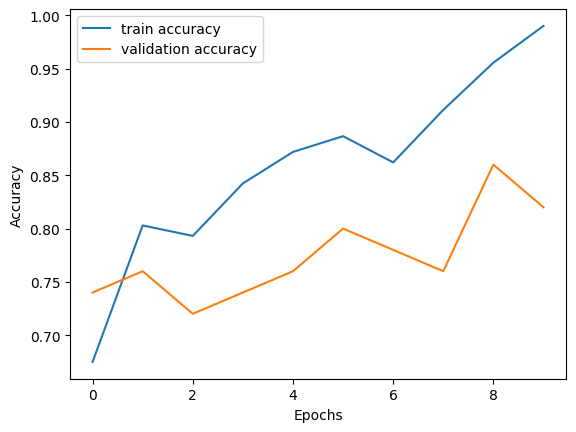

In [10]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.show()